# Segment CelebA Hairstyles

In [3]:
from pathlib import Path
import sys

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

PROJECT_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon')

In [4]:
import json
from pathlib import Path

import pandas as pd
from PIL import Image

from systems.static_auto_tryon.auto_app.core.hair_segmentation import predict_hair_mask_image, SEGMENTATION_CHECKPOINT_PATH
from systems.static_auto_tryon.auto_app.ml.celeba_hair_rich import build_celeba_seed_table, select_lightweight_celeba_subset, build_subset_record, write_jsonl

RAW_CELEBA_ROOT = BACKEND_ROOT / 'data' / 'raw' / 'celeba'
DATASET_ROOT = BACKEND_ROOT / 'data' / 'datasets' / 'celeba_hair_rich'
MASK_OUTPUT_DIR = DATASET_ROOT / 'segmentation_masks'
SUBSET_MANIFEST_PATH = DATASET_ROOT / 'lightweight_subset.jsonl'

LIGHTWEIGHT_MODE = False
MAX_TRAIN = 400 if LIGHTWEIGHT_MODE else 4000
MAX_VAL = 100 if LIGHTWEIGHT_MODE else 1000
MAX_TEST = 100 if LIGHTWEIGHT_MODE else 1000

print('Checkpoint:', SEGMENTATION_CHECKPOINT_PATH)
print('Dataset root:', DATASET_ROOT)

Checkpoint: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\checkpoints\hair_segmentation\v2_unet_product.pt
Dataset root: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\data\datasets\celeba_hair_rich


In [5]:
seed_table = build_celeba_seed_table(RAW_CELEBA_ROOT)
subset_table = select_lightweight_celeba_subset(seed_table, max_train=MAX_TRAIN, max_val=MAX_VAL, max_test=MAX_TEST)

print('Total seed rows:', len(seed_table))
print('Subset rows:', len(subset_table))
display(subset_table[['partition_name', 'gender_label']].value_counts().rename('count').to_frame())
subset_table.head()

Total seed rows: 202599
Subset rows: 6000


count
partition_name gender_label       
train          female         2540
               male           1460
test           female          669
val            female          605
               male            395
test           male            331

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,partition,partition_name,has_visible_hair_signal,gender_label
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,1,-1,1,-1,-1,1,0,train,True,female
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,-1,-1,-1,-1,1,0,train,True,female
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,1,0,train,True,male
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,1,-1,1,1,-1,1,0,train,True,female
4,000006.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,1,-1,1,-1,-1,1,0,train,True,female


In [6]:
subset_records = [build_subset_record(RAW_CELEBA_ROOT, row) for _, row in subset_table.iterrows()]
write_jsonl(subset_records, SUBSET_MANIFEST_PATH)
print('Saved subset manifest to', SUBSET_MANIFEST_PATH)
subset_records[0] if subset_records else None

Saved subset manifest to D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\data\datasets\celeba_hair_rich\lightweight_subset.jsonl


{'image_id': '000001.jpg',
 'image_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\raw\\celeba\\img_align_celeba\\img_align_celeba\\000001.jpg',
 'partition': 'train',
 'gender_label': 'female',
 'celeba_attributes': {'Male': -1,
  'Bald': -1,
  'Bangs': -1,
  'Black_Hair': -1,
  'Blond_Hair': -1,
  'Brown_Hair': 1,
  'Gray_Hair': -1,
  'Straight_Hair': 1,
  'Wavy_Hair': -1,
  'Receding_Hairline': -1,
  'Wearing_Hat': -1}}

In [7]:
MASK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

created = []
for record in subset_records:
    image_path = Path(record['image_path'])
    output_path = MASK_OUTPUT_DIR / f"{image_path.stem}_hair_mask.png"
    if output_path.exists():
        created.append(str(output_path))
        continue

    with Image.open(image_path) as source_image:
        mask_image = predict_hair_mask_image(source_image)
    mask_image.save(output_path)
    created.append(str(output_path))

print('Masks available:', len(created))
created[:3]

Masks available: 6000


['D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\datasets\\celeba_hair_rich\\segmentation_masks\\000001_hair_mask.png',
 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\datasets\\celeba_hair_rich\\segmentation_masks\\000002_hair_mask.png',
 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\datasets\\celeba_hair_rich\\segmentation_masks\\000003_hair_mask.png']

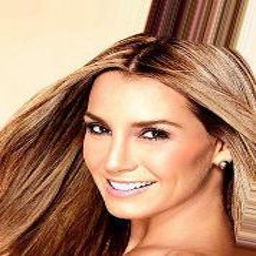

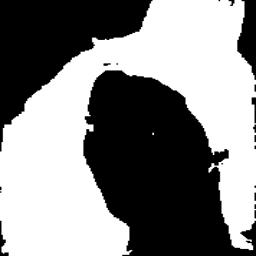

{'image_id': '000001.jpg', 'image_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\raw\\celeba\\img_align_celeba\\img_align_celeba\\000001.jpg', 'partition': 'train', 'gender_label': 'female', 'celeba_attributes': {'Male': -1, 'Bald': -1, 'Bangs': -1, 'Black_Hair': -1, 'Blond_Hair': -1, 'Brown_Hair': 1, 'Gray_Hair': -1, 'Straight_Hair': 1, 'Wavy_Hair': -1, 'Receding_Hairline': -1, 'Wearing_Hat': -1}}


In [8]:
preview_record = subset_records[0]
preview_image_path = Path(preview_record['image_path'])
preview_mask_path = MASK_OUTPUT_DIR / f"{preview_image_path.stem}_hair_mask.png"

display(Image.open(preview_image_path).convert('RGB').resize((256, 256)))
display(Image.open(preview_mask_path).convert('L').resize((256, 256)))
print(preview_record)